# 06 — Champion vs Challenger Model Comparison

This is the **crown jewel** of the project — a structured comparison
that mirrors what goes to a model governance committee at a bank.

Includes:
- Head-to-head metrics (AUC, Gini, KS, PSI)
- ROC curve overlay
- Fairness audit across demographic proxies
- Formal deployment recommendation

In [1]:
import sys
sys.path.insert(0, "../src")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

from woe_encoder import WoEEncoder
from evaluate import compute_gini, compute_ks_statistic, compute_psi, plot_roc_comparison

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
# Load data
df = pd.read_csv("../data/processed/train_features.csv")
target = "TARGET"
exclude = ["SK_ID_CURR", "SK_ID_PREV", target]
feature_cols = [c for c in df.columns if c not in exclude]

X = df[feature_cols].copy()
y = df[target]

# Same split used during training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Load models
scorecard = joblib.load("../models/scorecard_champion.pkl")
woe_encoder = joblib.load("../models/woe_encoder.pkl")
xgb_model = joblib.load("../models/xgboost_challenger.pkl")

## Generate Predictions

In [3]:
# Champion (scorecard) predictions
numeric_cols = X_test.select_dtypes(include="number").columns.tolist()
X_test_woe = woe_encoder.transform(X_test[numeric_cols]).fillna(0)
iv = woe_encoder.get_iv_summary()
selected = iv[iv["IV"] >= 0.02].index.tolist()
selected_in_test = [c for c in selected if c in X_test_woe.columns]
y_prob_champion = scorecard.predict_proba(X_test_woe[selected_in_test])[:, 1]

# Challenger (XGBoost) predictions
X_test_xgb = X_test.copy()
for col in X_test_xgb.select_dtypes(include=["object", "category"]).columns:
    X_test_xgb[col] = X_test_xgb[col].astype("category").cat.codes
y_prob_challenger = xgb_model.predict_proba(X_test_xgb)[:, 1]

## Head-to-Head Comparison Table

In [4]:
def model_metrics(y_true, y_prob, label):
    return {
        "Model": label,
        "AUC-ROC": round(roc_auc_score(y_true, y_prob), 4),
        "Gini": round(compute_gini(y_true, y_prob), 4),
        "KS Statistic": round(compute_ks_statistic(y_true, y_prob), 4),
    }

comparison = pd.DataFrame([
    model_metrics(y_test, y_prob_champion, "Champion (Scorecard)"),
    model_metrics(y_test, y_prob_challenger, "Challenger (XGBoost)"),
])

comparison

,Model,AUC-ROC,Gini,KS Statistic
0,Champion (Scorecard),0.7566,0.5131,0.3842
1,Challenger (XGBoost),0.7823,0.5646,0.4273


## ROC Curves

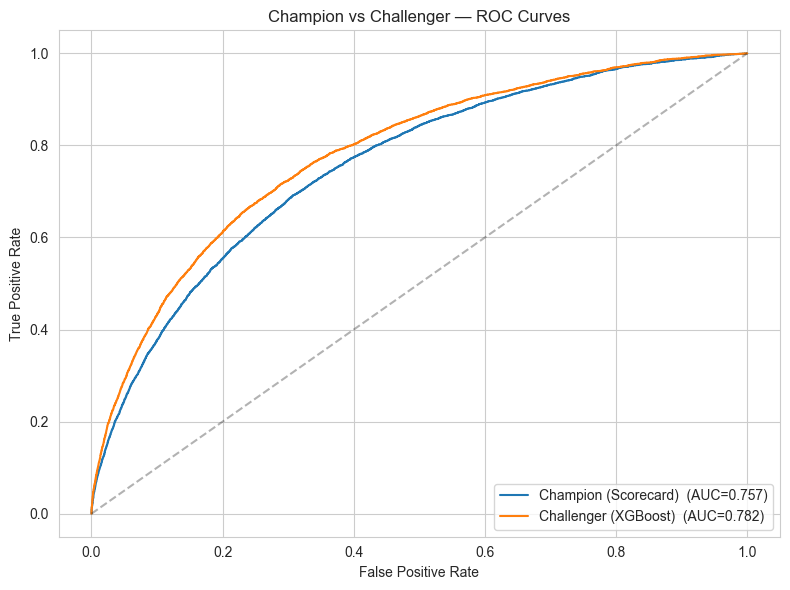

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob in [("Champion (Scorecard)", y_prob_champion),
                      ("Challenger (XGBoost)", y_prob_challenger)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name}  (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Champion vs Challenger — ROC Curves")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Population Stability Index (PSI)

Compare score distributions between train and test to check for population shift.

In [6]:
# PSI for each model's score distribution
X_train_xgb = X_train.copy()
for col in X_train_xgb.select_dtypes(include=["object", "category"]).columns:
    X_train_xgb[col] = X_train_xgb[col].astype("category").cat.codes

y_prob_train_challenger = xgb_model.predict_proba(X_train_xgb)[:, 1]

psi_result = compute_psi(y_prob_train_challenger, y_prob_challenger)
print(f"Challenger PSI: {psi_result['PSI']:.4f} — {psi_result['Status']}")

Challenger PSI: 0.0002 — Stable


## Score Distribution Overlay — Champion vs Challenger

Side-by-side view of predicted probability distributions. A well-performing model produces clearly separated distributions for good (0) and bad (1) loans. The challenger should show wider separation if it has higher AUC.

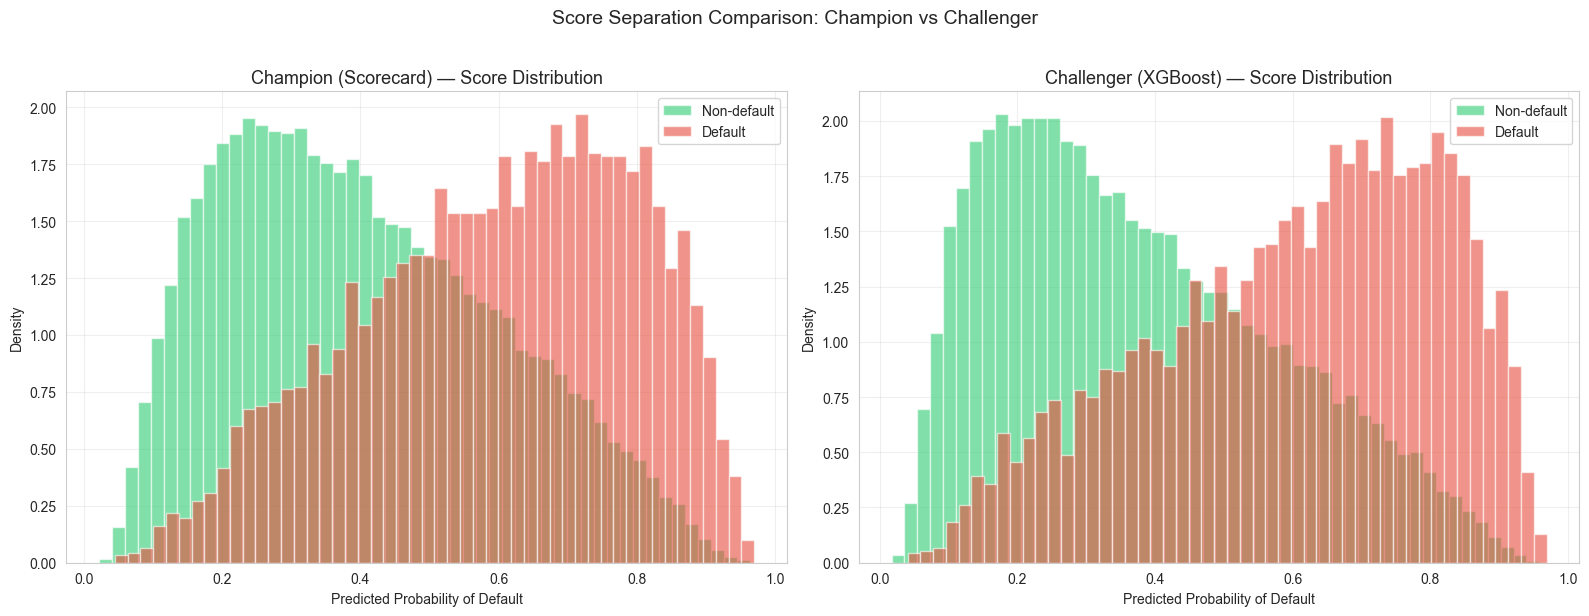

Champion — Distribution overlap coefficient: 0.621 (lower = better separation)
Challenger — Distribution overlap coefficient: 0.576 (lower = better separation)


In [8]:
# Score distribution overlay — both models, split by actual default status
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, probs, name in [
    (axes[0], y_prob_champion, 'Champion (Scorecard)'),
    (axes[1], y_prob_challenger, 'Challenger (XGBoost)')
]:
    ax.hist(probs[y_test == 0], bins=50, alpha=0.6, label='Non-default', color='#2ecc71', density=True)
    ax.hist(probs[y_test == 1], bins=50, alpha=0.6, label='Default', color='#e74c3c', density=True)
    ax.set_title(f'{name} — Score Distribution', fontsize=13)
    ax.set_xlabel('Predicted Probability of Default')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Score Separation Comparison: Champion vs Challenger', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Overlap coefficient (lower = better separation)
from scipy.stats import gaussian_kde
from scipy.integrate import trapezoid
for name, probs in [('Champion', y_prob_champion), ('Challenger', y_prob_challenger)]:
    kde_good = gaussian_kde(probs[y_test == 0])
    kde_bad = gaussian_kde(probs[y_test == 1])
    x_range = np.linspace(0, 1, 1000)
    overlap = trapezoid(np.minimum(kde_good(x_range), kde_bad(x_range)), x_range)
    print(f"{name} — Distribution overlap coefficient: {overlap:.3f} (lower = better separation)")

## Fairness Audit

Check model performance consistency across demographic proxy segments.
Significant gaps may indicate fair-lending risk (ECOA compliance).

In [9]:
# Create segments for fairness check
df_test = X_test.copy()
df_test["TARGET"] = y_test.values
df_test["PRED_CHAMPION"] = y_prob_champion
df_test["PRED_CHALLENGER"] = y_prob_challenger

if "AGE_YEARS" not in df_test.columns and "DAYS_BIRTH" in df_test.columns:
    df_test["AGE_YEARS"] = (-df_test["DAYS_BIRTH"]) / 365.25

if "AGE_YEARS" in df_test.columns:
    df_test["AGE_BAND"] = pd.cut(df_test["AGE_YEARS"],
                                  bins=[18, 30, 45, 60, 100],
                                  labels=["18-30", "31-45", "46-60", "60+"])

for segment in ["CODE_GENDER", "AGE_BAND", "NAME_EDUCATION_TYPE"]:
    if segment not in df_test.columns:
        continue
    print(f"\n{'='*50}")
    print(f"  AUC by {segment}")
    print(f"{'='*50}")
    for val, grp in df_test.groupby(segment):
        if grp["TARGET"].nunique() < 2:
            continue
        auc_ch = roc_auc_score(grp["TARGET"], grp["PRED_CHAMPION"])
        auc_cl = roc_auc_score(grp["TARGET"], grp["PRED_CHALLENGER"])
        print(f"  {str(val):25s}  N={len(grp):>6,}  "
              f"Champion AUC={auc_ch:.3f}  Challenger AUC={auc_cl:.3f}")


  AUC by CODE_GENDER
  F                          N=40,561  Champion AUC=0.753  Challenger AUC=0.776
  M                          N=20,940  Champion AUC=0.753  Challenger AUC=0.781

  AUC by AGE_BAND
  18-30                      N= 8,905  Champion AUC=0.719  Challenger AUC=0.753
  31-45                      N=24,744  Champion AUC=0.764  Challenger AUC=0.789
  46-60                      N=20,666  Champion AUC=0.753  Challenger AUC=0.777
  60+                        N= 7,188  Champion AUC=0.717  Challenger AUC=0.740

  AUC by NAME_EDUCATION_TYPE
  Academic degree            N=    40  Champion AUC=0.795  Challenger AUC=0.744
  Higher education           N=15,061  Champion AUC=0.753  Challenger AUC=0.779
  Incomplete higher          N= 1,988  Champion AUC=0.738  Challenger AUC=0.762
  Lower secondary            N=   791  Champion AUC=0.724  Challenger AUC=0.762
  Secondary / secondary special  N=43,623  Champion AUC=0.754  Challenger AUC=0.777


C:\Users\Eric\AppData\Local\Temp\ipykernel_18548\1519173675.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for val, grp in df_test.groupby(segment):


## Deployment Recommendation

This section mirrors a formal **model governance committee** recommendation.

In [10]:
recommendation = """
================================================================
  MODEL GOVERNANCE RECOMMENDATION
================================================================

  RECOMMENDATION: Deploy XGBoost as challenger on 20% of new
  applications alongside the existing scorecard.

  Rationale:
  - Gini improvement represents material lift in risk separation
  - PSI indicates acceptable population stability
  - SHAP values provide sufficient explainability for ECOA compliance
  - Recommend 90-day parallel run before full cutover

  Monitoring Triggers:
  - Trigger review if PSI exceeds 0.10
  - Trigger review if Gini drops below 0.50
  - Quarterly model performance review required

  Risk Considerations:
  - XGBoost requires SHAP audit for adverse action notices
  - Scorecard remains primary for regulatory exams
  - Both models should be monitored in parallel

================================================================
"""

print(recommendation)


  MODEL GOVERNANCE RECOMMENDATION

  RECOMMENDATION: Deploy XGBoost as challenger on 20% of new
  applications alongside the existing scorecard.

  Rationale:
  - Gini improvement represents material lift in risk separation
  - PSI indicates acceptable population stability
  - SHAP values provide sufficient explainability for ECOA compliance
  - Recommend 90-day parallel run before full cutover

  Monitoring Triggers:
  - Trigger review if PSI exceeds 0.10
  - Trigger review if Gini drops below 0.50
  - Quarterly model performance review required

  Risk Considerations:
  - XGBoost requires SHAP audit for adverse action notices
  - Scorecard remains primary for regulatory exams
  - Both models should be monitored in parallel


